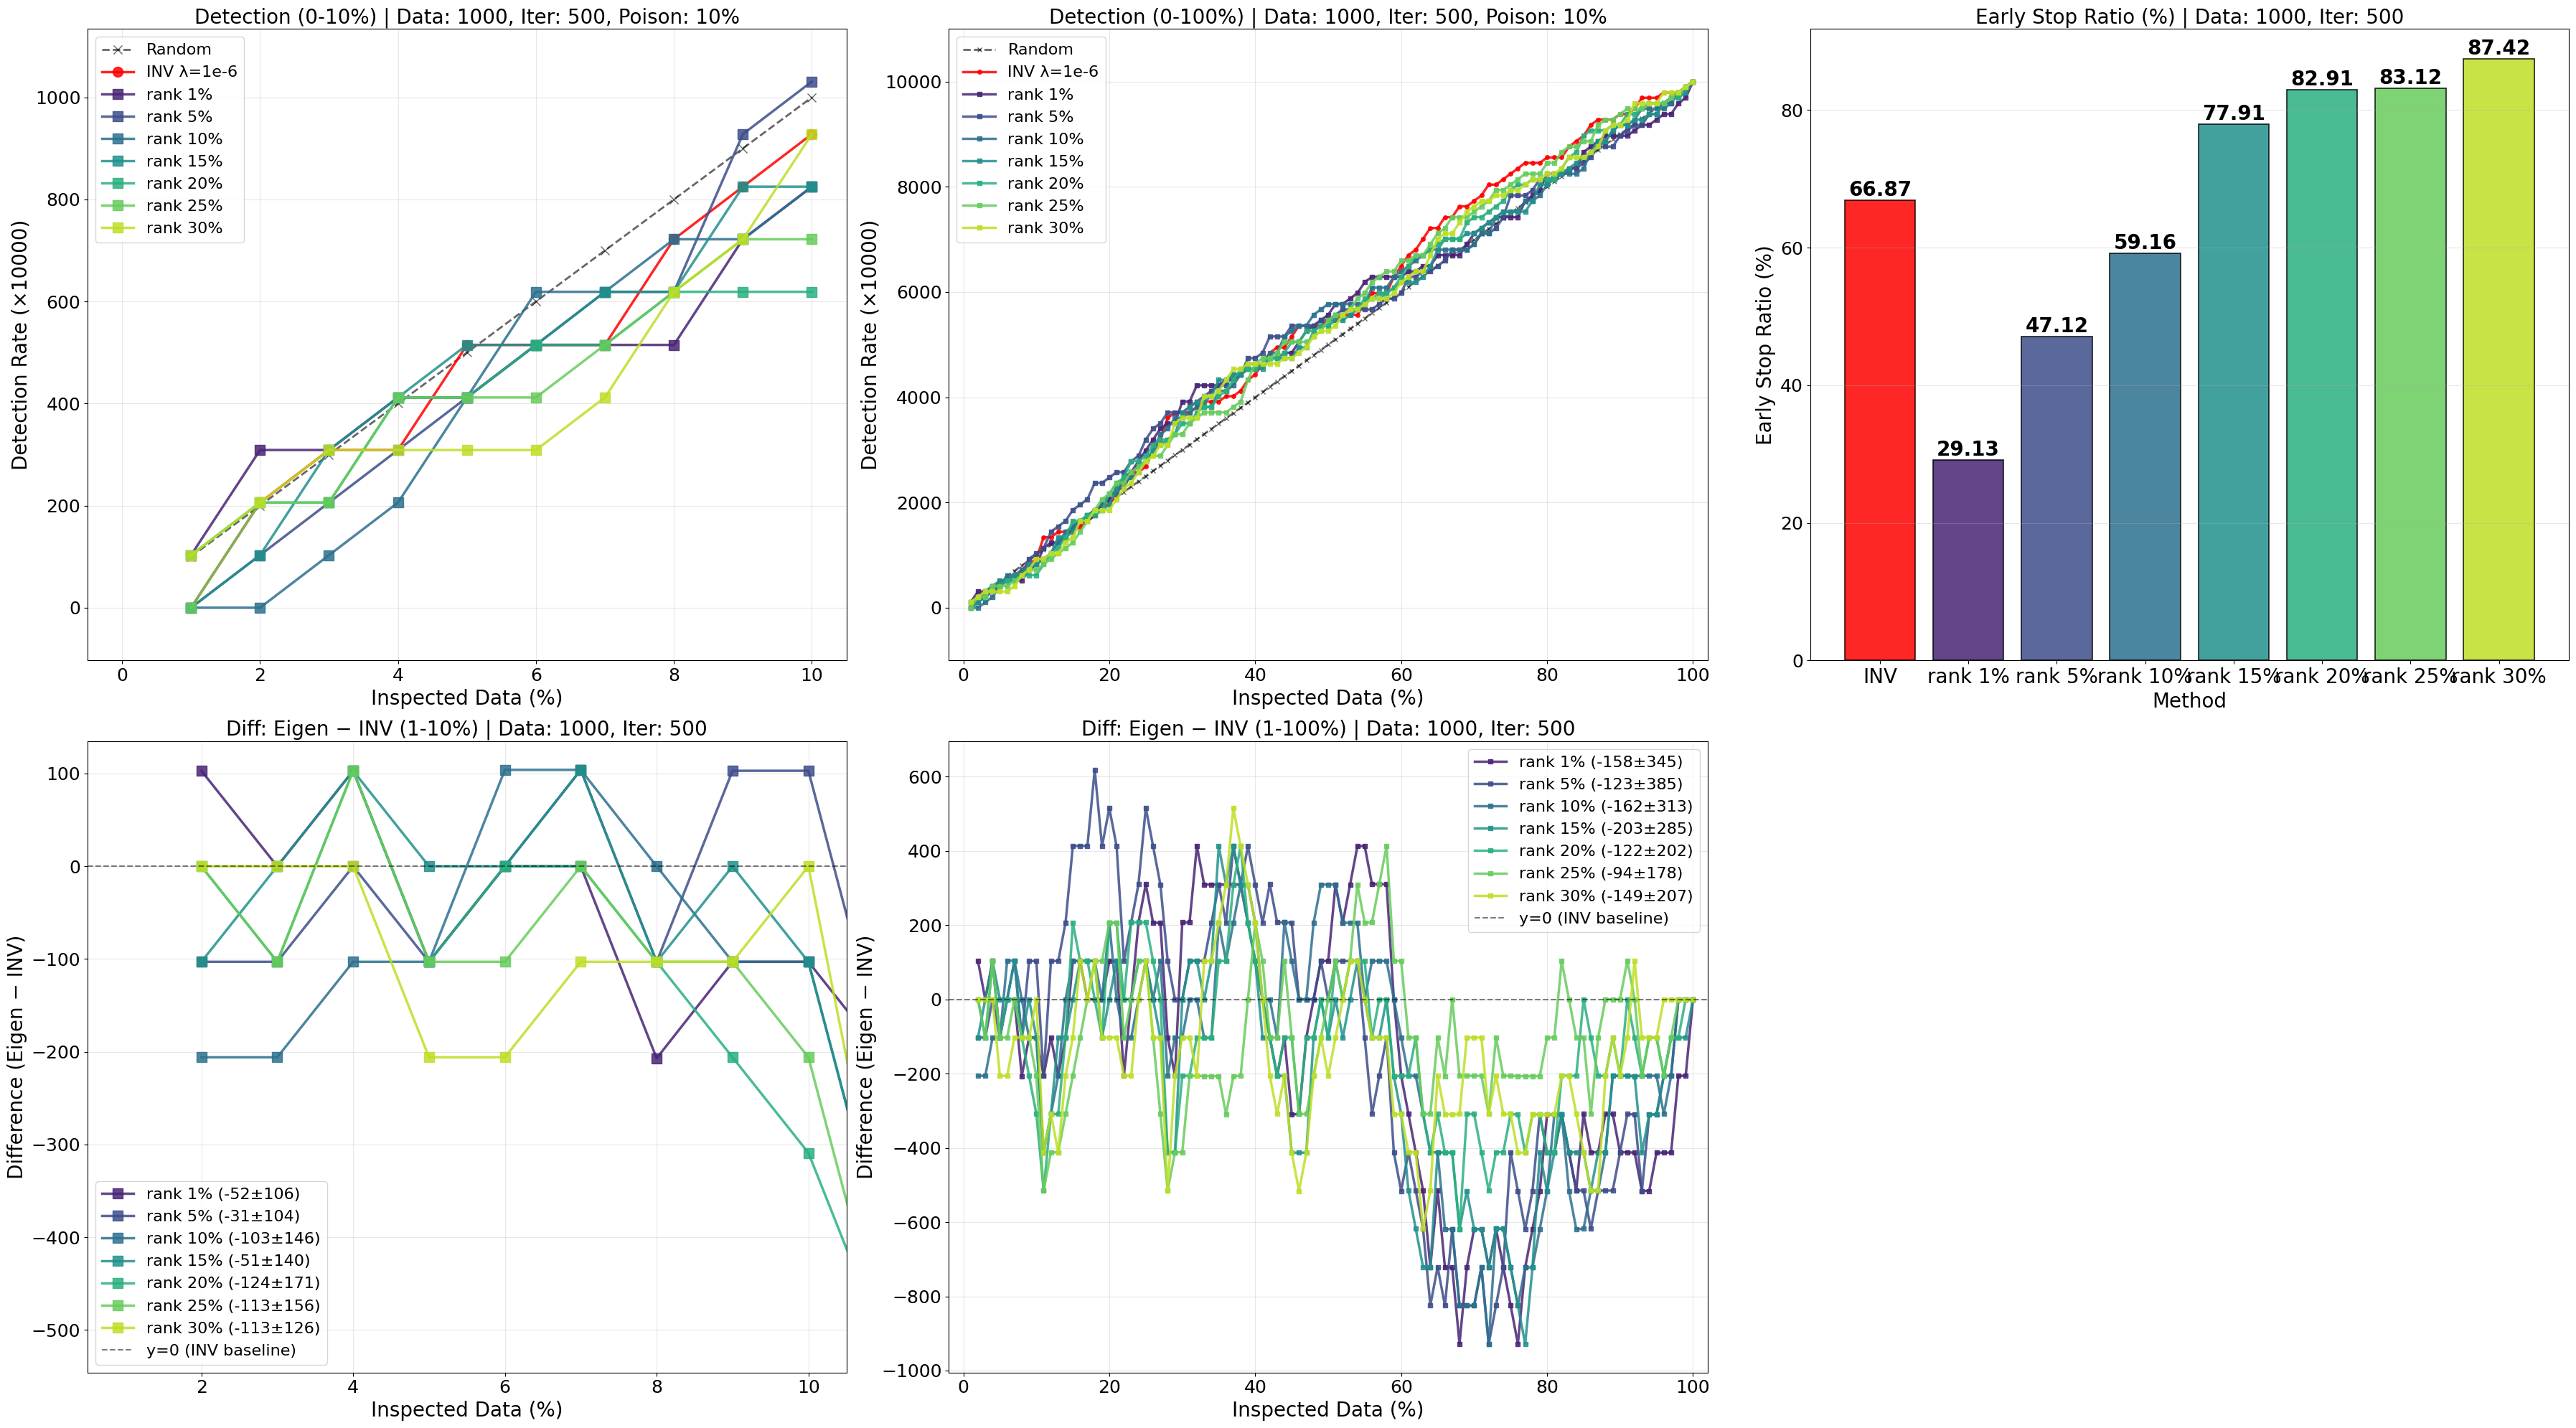

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [0, 206, 309, 309, 515, 515, 515, 722, 825, 928, 1340, 1340, 1443, 1443, 1443, 1546, 1649, 1753, 1959, 1959, 2165, 2474, 2577, 2577, 2680, 2990, 3196, 3608, 3711, 3711, 3711, 3814, 3918, 3918, 3918, 4021, 4021, 4124, 4330, 4433, 4639, 4845, 4948, 4948, 5155, 5361, 5361, 5361, 5361, 5464, 5464, 5567, 5567, 5567, 5773, 5979, 5979, 5979, 6289, 6495, 6701, 6804, 7010, 7216, 7216, 7423, 7423, 7629, 7629, 7732, 7835, 8041, 8041, 8144, 8247, 8351, 8454, 8454, 8454, 8557, 8557, 8557, 8763, 8866, 8969, 9175, 9278, 9278, 9278, 9381, 9381, 9485, 9691, 9691, 9691, 9794, 9794, 9794, 9897, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [103, 309, 309, 412, 412, 515, 515, 515, 722, 825, 1134, 1237, 1237, 1340, 1546, 1649, 1649, 1753, 1959, 2062, 2268, 2268, 2577, 2784, 2990, 3196, 3402, 3505, 3505, 3918, 3918, 4227, 4227, 4227, 4227, 4330, 4330, 4433, 4536, 4536, 4639, 4742, 4742, 4845, 4845, 5052, 5258, 5361, 5464, 5567, 5773, 5773, 5876, 5979, 6186, 6289, 6289, 6289, 6289, 6289, 6392, 6392, 6495, 6495, 6701, 6701, 6701, 6701, 6907, 7113, 7216, 7320, 7423, 7423, 7423, 7423, 7732, 7835, 7938, 8247, 8247, 8247, 8351, 8351, 8660, 8763, 8866, 8969, 8969, 8969, 8969, 9072, 9175, 9175, 9278, 9381, 9381, 9588, 9691, 10000]
r5_eigen_lam1e_2  = [0, 103, 206, 309, 412, 515, 619, 619, 928, 1031, 1134, 1443, 1546, 1649, 1856, 1959, 2062, 2371, 2371, 2474, 2577, 2577, 2784, 2887, 3196, 3402, 3505, 3711, 3711, 3711, 3814, 3918, 4021, 4124, 4227, 4227, 4433, 4433, 4742, 4742, 4845, 5155, 5155, 5155, 5361, 5361, 5361, 5361, 5464, 5464, 5567, 5670, 5670, 5670, 5670, 5670, 5773, 5876, 5876, 5979, 6289, 6289, 6392, 6392, 6495, 6598, 6804, 6804, 6804, 6907, 7113, 7113, 7216, 7423, 7835, 7835, 7835, 7938, 8144, 8144, 8144, 8247, 8351, 8351, 8454, 8557, 8763, 8763, 8763, 8969, 9072, 9175, 9175, 9381, 9381, 9588, 9588, 9794, 9897, 10000]
r10_eigen_lam1e_2 = [0, 0, 103, 206, 412, 619, 619, 722, 722, 825, 928, 1031, 1237, 1443, 1546, 1649, 1753, 1856, 1959, 2165, 2165, 2371, 2474, 2577, 2784, 2990, 3299, 3402, 3608, 3608, 3711, 3814, 3814, 3814, 4124, 4124, 4227, 4433, 4639, 4639, 4639, 4845, 4845, 5155, 5258, 5361, 5361, 5567, 5670, 5773, 5773, 5773, 5773, 5773, 5773, 6082, 6082, 6082, 6289, 6392, 6495, 6598, 6701, 6804, 6804, 6804, 6804, 6804, 6804, 6907, 7113, 7113, 7423, 7526, 7526, 7526, 7732, 7732, 7835, 8041, 8247, 8247, 8247, 8247, 8351, 8660, 8763, 8866, 9072, 9175, 9175, 9278, 9485, 9485, 9485, 9485, 9588, 9794, 9897, 10000]
r15_eigen_lam1e_2 = [0, 103, 309, 412, 515, 515, 619, 619, 825, 825, 928, 1031, 1340, 1340, 1443, 1649, 1753, 1856, 1856, 1959, 2268, 2474, 2577, 2680, 2784, 2990, 3093, 3196, 3299, 3711, 3814, 3918, 3918, 4021, 4330, 4330, 4433, 4433, 4536, 4536, 4536, 4742, 4742, 4742, 4742, 4948, 4948, 5258, 5361, 5361, 5464, 5464, 5567, 5670, 5773, 5876, 5876, 5979, 6082, 6186, 6186, 6186, 6289, 6495, 6804, 7010, 7010, 7010, 7113, 7113, 7216, 7320, 7423, 7526, 7526, 7526, 7526, 7732, 8041, 8041, 8144, 8247, 8351, 8454, 8557, 8660, 8866, 8866, 9072, 9175, 9175, 9278, 9278, 9381, 9381, 9588, 9691, 9691, 9794, 10000]
r20_eigen_lam1e_2 = [103, 206, 206, 412, 412, 515, 515, 619, 619, 619, 825, 1031, 1134, 1340, 1649, 1649, 1753, 1753, 1856, 2165, 2371, 2474, 2784, 2784, 2887, 3093, 3196, 3196, 3299, 3505, 3505, 3711, 3814, 3814, 4021, 4124, 4330, 4536, 4536, 4536, 4639, 4742, 4742, 4845, 5052, 5052, 5258, 5258, 5361, 5361, 5567, 5567, 5670, 5670, 5876, 5876, 5979, 5979, 6082, 6289, 6495, 6701, 6701, 6804, 6907, 7010, 7010, 7010, 7320, 7423, 7423, 7526, 7629, 7732, 7938, 8041, 8041, 8144, 8144, 8144, 8144, 8351, 8557, 8660, 8969, 9072, 9072, 9072, 9175, 9175, 9381, 9381, 9485, 9588, 9588, 9588, 9691, 9691, 9897, 10000]
r25_eigen_lam1e_2 = [0, 206, 206, 412, 412, 412, 515, 619, 722, 722, 825, 928, 1031, 1134, 1237, 1443, 1649, 1856, 2062, 2165, 2371, 2371, 2577, 2680, 2784, 2887, 2887, 3093, 3299, 3299, 3505, 3608, 3711, 3711, 3711, 3711, 3814, 3918, 4330, 4639, 4742, 4742, 4845, 5052, 5052, 5052, 5052, 5155, 5258, 5464, 5567, 5567, 5670, 5876, 5979, 6186, 6289, 6392, 6392, 6598, 6598, 6701, 6701, 6907, 7113, 7216, 7423, 7423, 7423, 7526, 7629, 7732, 7938, 7938, 8041, 8144, 8247, 8247, 8247, 8454, 8454, 8660, 8763, 8763, 8866, 8866, 9175, 9278, 9278, 9381, 9485, 9485, 9485, 9588, 9588, 9588, 9691, 9794, 9897, 10000]
r30_eigen_lam1e_2 = [103, 206, 309, 309, 309, 309, 412, 619, 722, 928, 928, 1031, 1031, 1237, 1340, 1649, 1649, 1856, 1856, 1856, 2062, 2268, 2371, 2577, 2784, 2887, 3093, 3093, 3505, 3608, 3608, 3608, 4021, 4021, 4124, 4330, 4536, 4536, 4639, 4639, 4639, 4639, 4639, 4742, 4742, 4845, 4948, 5155, 5258, 5258, 5361, 5567, 5670, 5670, 5773, 5876, 5876, 5876, 5979, 6186, 6289, 6392, 6392, 6701, 7010, 7113, 7113, 7320, 7526, 7629, 7732, 7732, 7835, 7835, 7938, 7938, 8041, 8144, 8144, 8247, 8247, 8351, 8557, 8557, 8557, 8660, 8763, 9072, 9175, 9175, 9278, 9588, 9588, 9588, 9588, 9794, 9794, 9794, 9897, 10000]

# Early stop ratios (%)
inv_early_stop       = [66.87]
r1_eigen_early_stop  = [29.13]
r5_eigen_early_stop  = [47.12]
r10_eigen_early_stop = [59.16]
r15_eigen_early_stop = [77.91]
r20_eigen_early_stop = [82.91]
r25_eigen_early_stop = [83.12]
r30_eigen_early_stop = [87.42]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

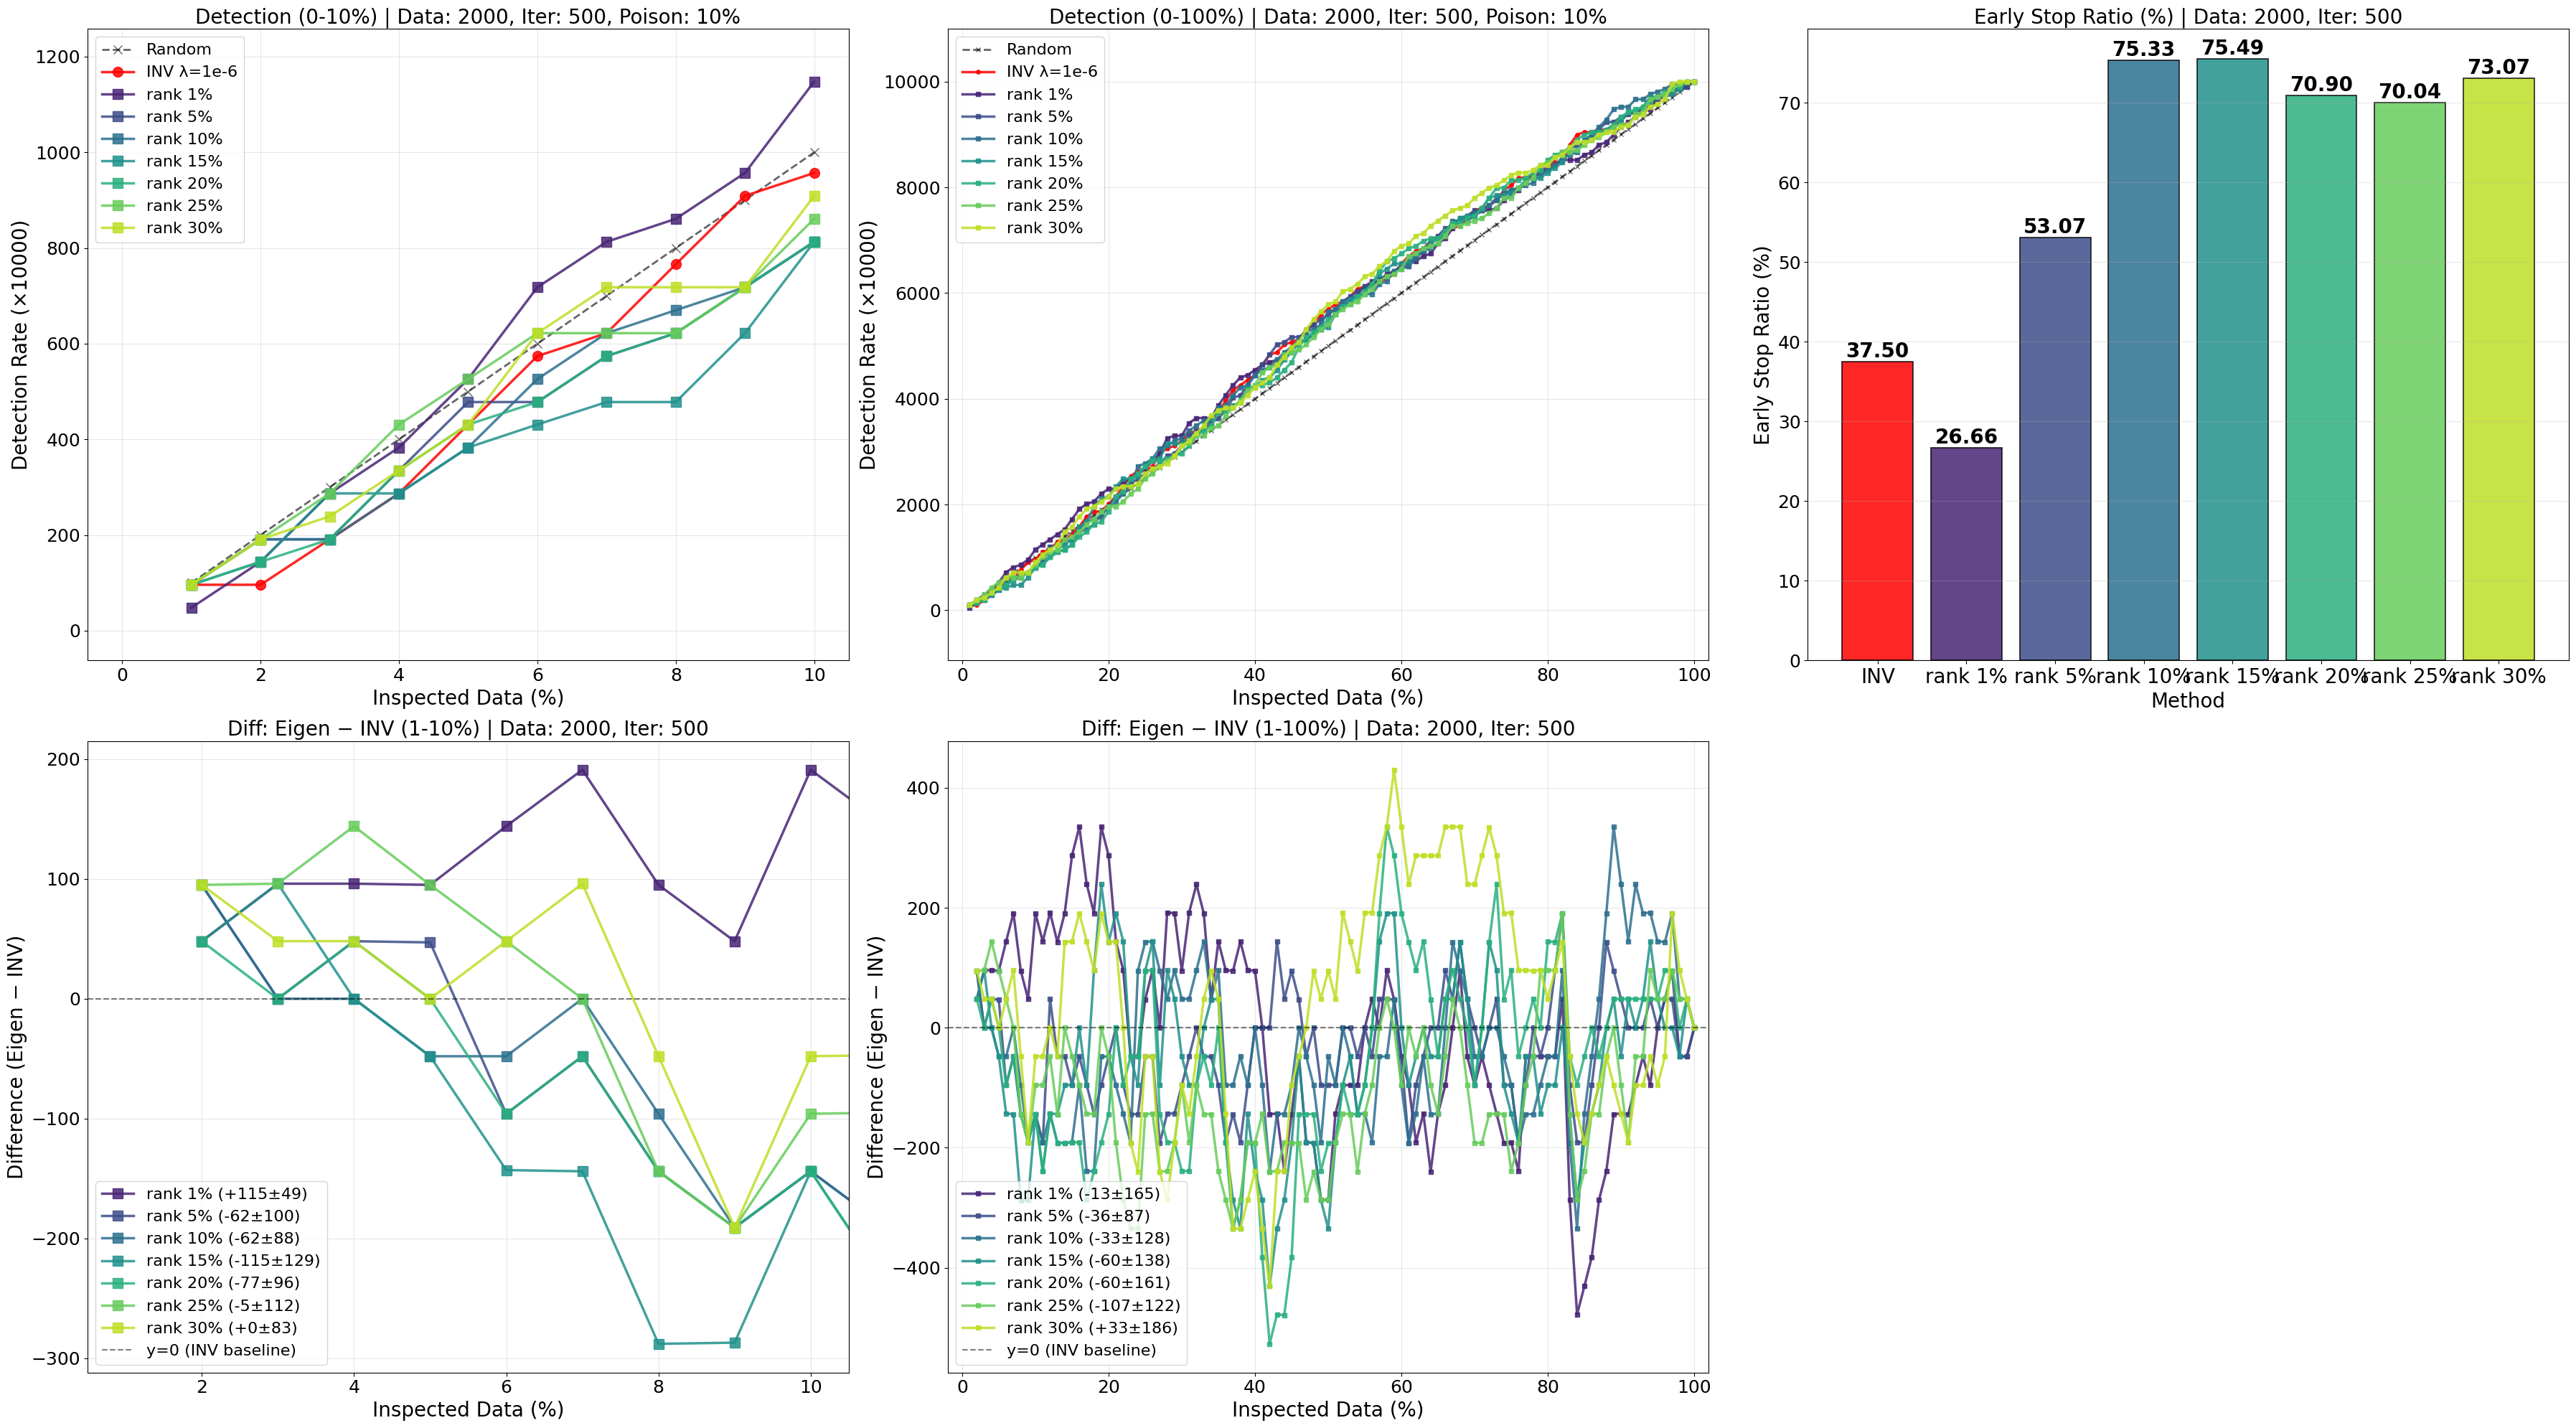

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [96, 96, 191, 287, 431, 574, 622, 766, 909, 957, 1100, 1148, 1292, 1340, 1435, 1579, 1770, 1866, 1866, 2010, 2153, 2344, 2536, 2632, 2632, 2727, 2967, 3062, 3110, 3206, 3349, 3397, 3445, 3589, 3732, 3971, 4163, 4258, 4354, 4450, 4641, 4833, 4880, 5024, 5072, 5120, 5311, 5407, 5598, 5694, 5789, 5837, 5933, 6077, 6124, 6172, 6220, 6268, 6364, 6555, 6699, 6794, 6842, 6986, 7081, 7129, 7225, 7273, 7416, 7560, 7608, 7656, 7751, 7943, 8038, 8182, 8182, 8230, 8325, 8373, 8469, 8469, 8804, 8995, 9043, 9043, 9091, 9091, 9139, 9282, 9378, 9426, 9474, 9569, 9665, 9713, 9761, 9904, 9952, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [48, 144, 287, 383, 526, 718, 813, 861, 957, 1148, 1244, 1340, 1435, 1531, 1722, 1914, 2010, 2057, 2201, 2297, 2297, 2440, 2488, 2584, 2679, 2823, 2967, 3254, 3301, 3301, 3541, 3636, 3636, 3636, 3876, 4067, 4258, 4402, 4450, 4545, 4641, 4689, 4737, 4785, 4928, 5072, 5120, 5215, 5311, 5407, 5646, 5742, 5837, 5981, 6124, 6220, 6220, 6364, 6411, 6507, 6603, 6603, 6699, 6746, 6938, 7033, 7225, 7368, 7368, 7464, 7560, 7560, 7608, 7751, 7847, 7943, 8134, 8182, 8278, 8325, 8421, 8517, 8517, 8517, 8612, 8660, 8804, 8852, 8995, 9139, 9234, 9330, 9426, 9474, 9665, 9761, 9856, 9856, 9904, 10000]
r5_eigen_lam1e_2  = [96, 191, 191, 335, 478, 478, 574, 622, 718, 813, 909, 1196, 1244, 1292, 1340, 1531, 1675, 1722, 1770, 1962, 2153, 2249, 2392, 2488, 2584, 2679, 2775, 2919, 2967, 3110, 3301, 3397, 3397, 3541, 3636, 3780, 4019, 4067, 4258, 4450, 4641, 4833, 5024, 5072, 5167, 5167, 5263, 5407, 5502, 5598, 5694, 5837, 5933, 6029, 6124, 6124, 6268, 6316, 6411, 6507, 6507, 6699, 6794, 6986, 7081, 7225, 7273, 7416, 7464, 7560, 7560, 7656, 7799, 7847, 7943, 7990, 8086, 8230, 8278, 8373, 8565, 8660, 8708, 8804, 8852, 8947, 9091, 9234, 9234, 9330, 9378, 9426, 9474, 9617, 9665, 9761, 9809, 9856, 9904, 10000]
r10_eigen_lam1e_2 = [96, 191, 191, 287, 383, 526, 622, 670, 718, 813, 909, 1005, 1100, 1148, 1244, 1483, 1531, 1627, 1818, 1962, 2057, 2201, 2344, 2727, 2775, 2871, 3062, 3110, 3206, 3254, 3397, 3493, 3589, 3636, 3828, 3876, 4067, 4211, 4258, 4450, 4545, 4593, 4737, 4880, 4976, 5120, 5263, 5311, 5407, 5646, 5694, 5837, 5885, 5933, 5981, 5981, 6172, 6220, 6411, 6459, 6507, 6651, 6794, 6842, 6938, 7129, 7368, 7368, 7464, 7512, 7560, 7656, 7751, 7895, 7943, 7990, 8038, 8086, 8230, 8325, 8421, 8565, 8612, 8660, 8900, 8995, 9139, 9282, 9474, 9522, 9522, 9665, 9665, 9761, 9809, 9856, 9952, 9952, 10000, 10000]
r15_eigen_lam1e_2 = [96, 144, 287, 287, 383, 431, 478, 478, 622, 813, 861, 1005, 1148, 1244, 1340, 1579, 1675, 1962, 2105, 2153, 2344, 2488, 2488, 2536, 2727, 2871, 2871, 3158, 3158, 3158, 3254, 3301, 3445, 3636, 3780, 3780, 3876, 3923, 4211, 4211, 4354, 4402, 4545, 4737, 4880, 5072, 5120, 5215, 5311, 5359, 5598, 5742, 5885, 5933, 6029, 6172, 6364, 6459, 6555, 6555, 6603, 6746, 6842, 6938, 7033, 7177, 7273, 7416, 7464, 7464, 7608, 7799, 7847, 7847, 7895, 7990, 8134, 8182, 8182, 8278, 8373, 8469, 8660, 8708, 8852, 8900, 8995, 9091, 9187, 9234, 9426, 9426, 9522, 9713, 9713, 9713, 9761, 9856, 10000, 10000]
r20_eigen_lam1e_2 = [96, 144, 191, 335, 431, 478, 574, 622, 718, 813, 861, 1005, 1100, 1148, 1244, 1388, 1483, 1627, 1675, 1866, 2153, 2249, 2488, 2584, 2727, 2823, 2823, 2871, 2919, 2967, 3110, 3301, 3397, 3493, 3732, 3780, 3828, 3971, 4163, 4258, 4258, 4306, 4402, 4545, 4689, 4976, 5167, 5263, 5359, 5502, 5598, 5742, 5789, 5933, 6029, 6172, 6411, 6603, 6651, 6746, 6842, 6890, 6986, 7033, 7033, 7177, 7321, 7321, 7416, 7464, 7608, 7799, 7990, 7990, 8134, 8134, 8182, 8278, 8325, 8517, 8612, 8660, 8756, 8900, 8995, 9043, 9043, 9091, 9187, 9330, 9426, 9474, 9522, 9617, 9713, 9809, 9856, 9904, 10000, 10000]
r25_eigen_lam1e_2 = [96, 191, 287, 431, 526, 622, 622, 622, 718, 861, 1005, 1100, 1148, 1340, 1388, 1483, 1627, 1722, 1866, 1962, 1962, 2057, 2201, 2297, 2488, 2584, 2727, 2823, 2919, 3110, 3158, 3301, 3301, 3445, 3493, 3684, 3828, 3971, 4163, 4258, 4498, 4593, 4641, 4833, 4880, 4928, 5024, 5167, 5311, 5407, 5598, 5694, 5789, 5837, 5981, 6077, 6220, 6316, 6364, 6459, 6699, 6746, 6842, 6890, 6938, 7081, 7273, 7273, 7321, 7368, 7416, 7512, 7608, 7799, 7799, 7990, 8086, 8182, 8421, 8469, 8565, 8660, 8660, 8708, 8804, 8900, 8947, 9043, 9139, 9187, 9187, 9378, 9426, 9665, 9713, 9761, 9856, 9952, 10000, 10000]
r30_eigen_lam1e_2 = [96, 191, 239, 335, 431, 622, 718, 718, 718, 909, 1053, 1148, 1244, 1483, 1579, 1770, 1914, 1962, 2057, 2153, 2297, 2344, 2344, 2392, 2584, 2679, 2727, 2775, 2919, 3110, 3206, 3349, 3493, 3684, 3780, 3828, 3828, 3923, 4067, 4211, 4306, 4402, 4641, 4785, 4976, 5072, 5311, 5502, 5646, 5789, 5837, 6029, 6077, 6172, 6316, 6364, 6507, 6603, 6794, 6890, 6938, 7081, 7129, 7273, 7368, 7464, 7560, 7608, 7656, 7799, 7895, 7990, 8038, 8134, 8230, 8278, 8278, 8325, 8421, 8421, 8565, 8612, 8756, 8852, 8852, 8900, 8995, 9043, 9043, 9139, 9187, 9330, 9378, 9522, 9569, 9665, 9952, 10000, 10000, 10000]

# Early stop ratios (%)
inv_early_stop       = [37.50]
r1_eigen_early_stop  = [26.66]
r5_eigen_early_stop  = [53.07]
r10_eigen_early_stop = [75.33]
r15_eigen_early_stop = [75.49]
r20_eigen_early_stop = [70.90]
r25_eigen_early_stop = [70.04]
r30_eigen_early_stop = [73.07]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

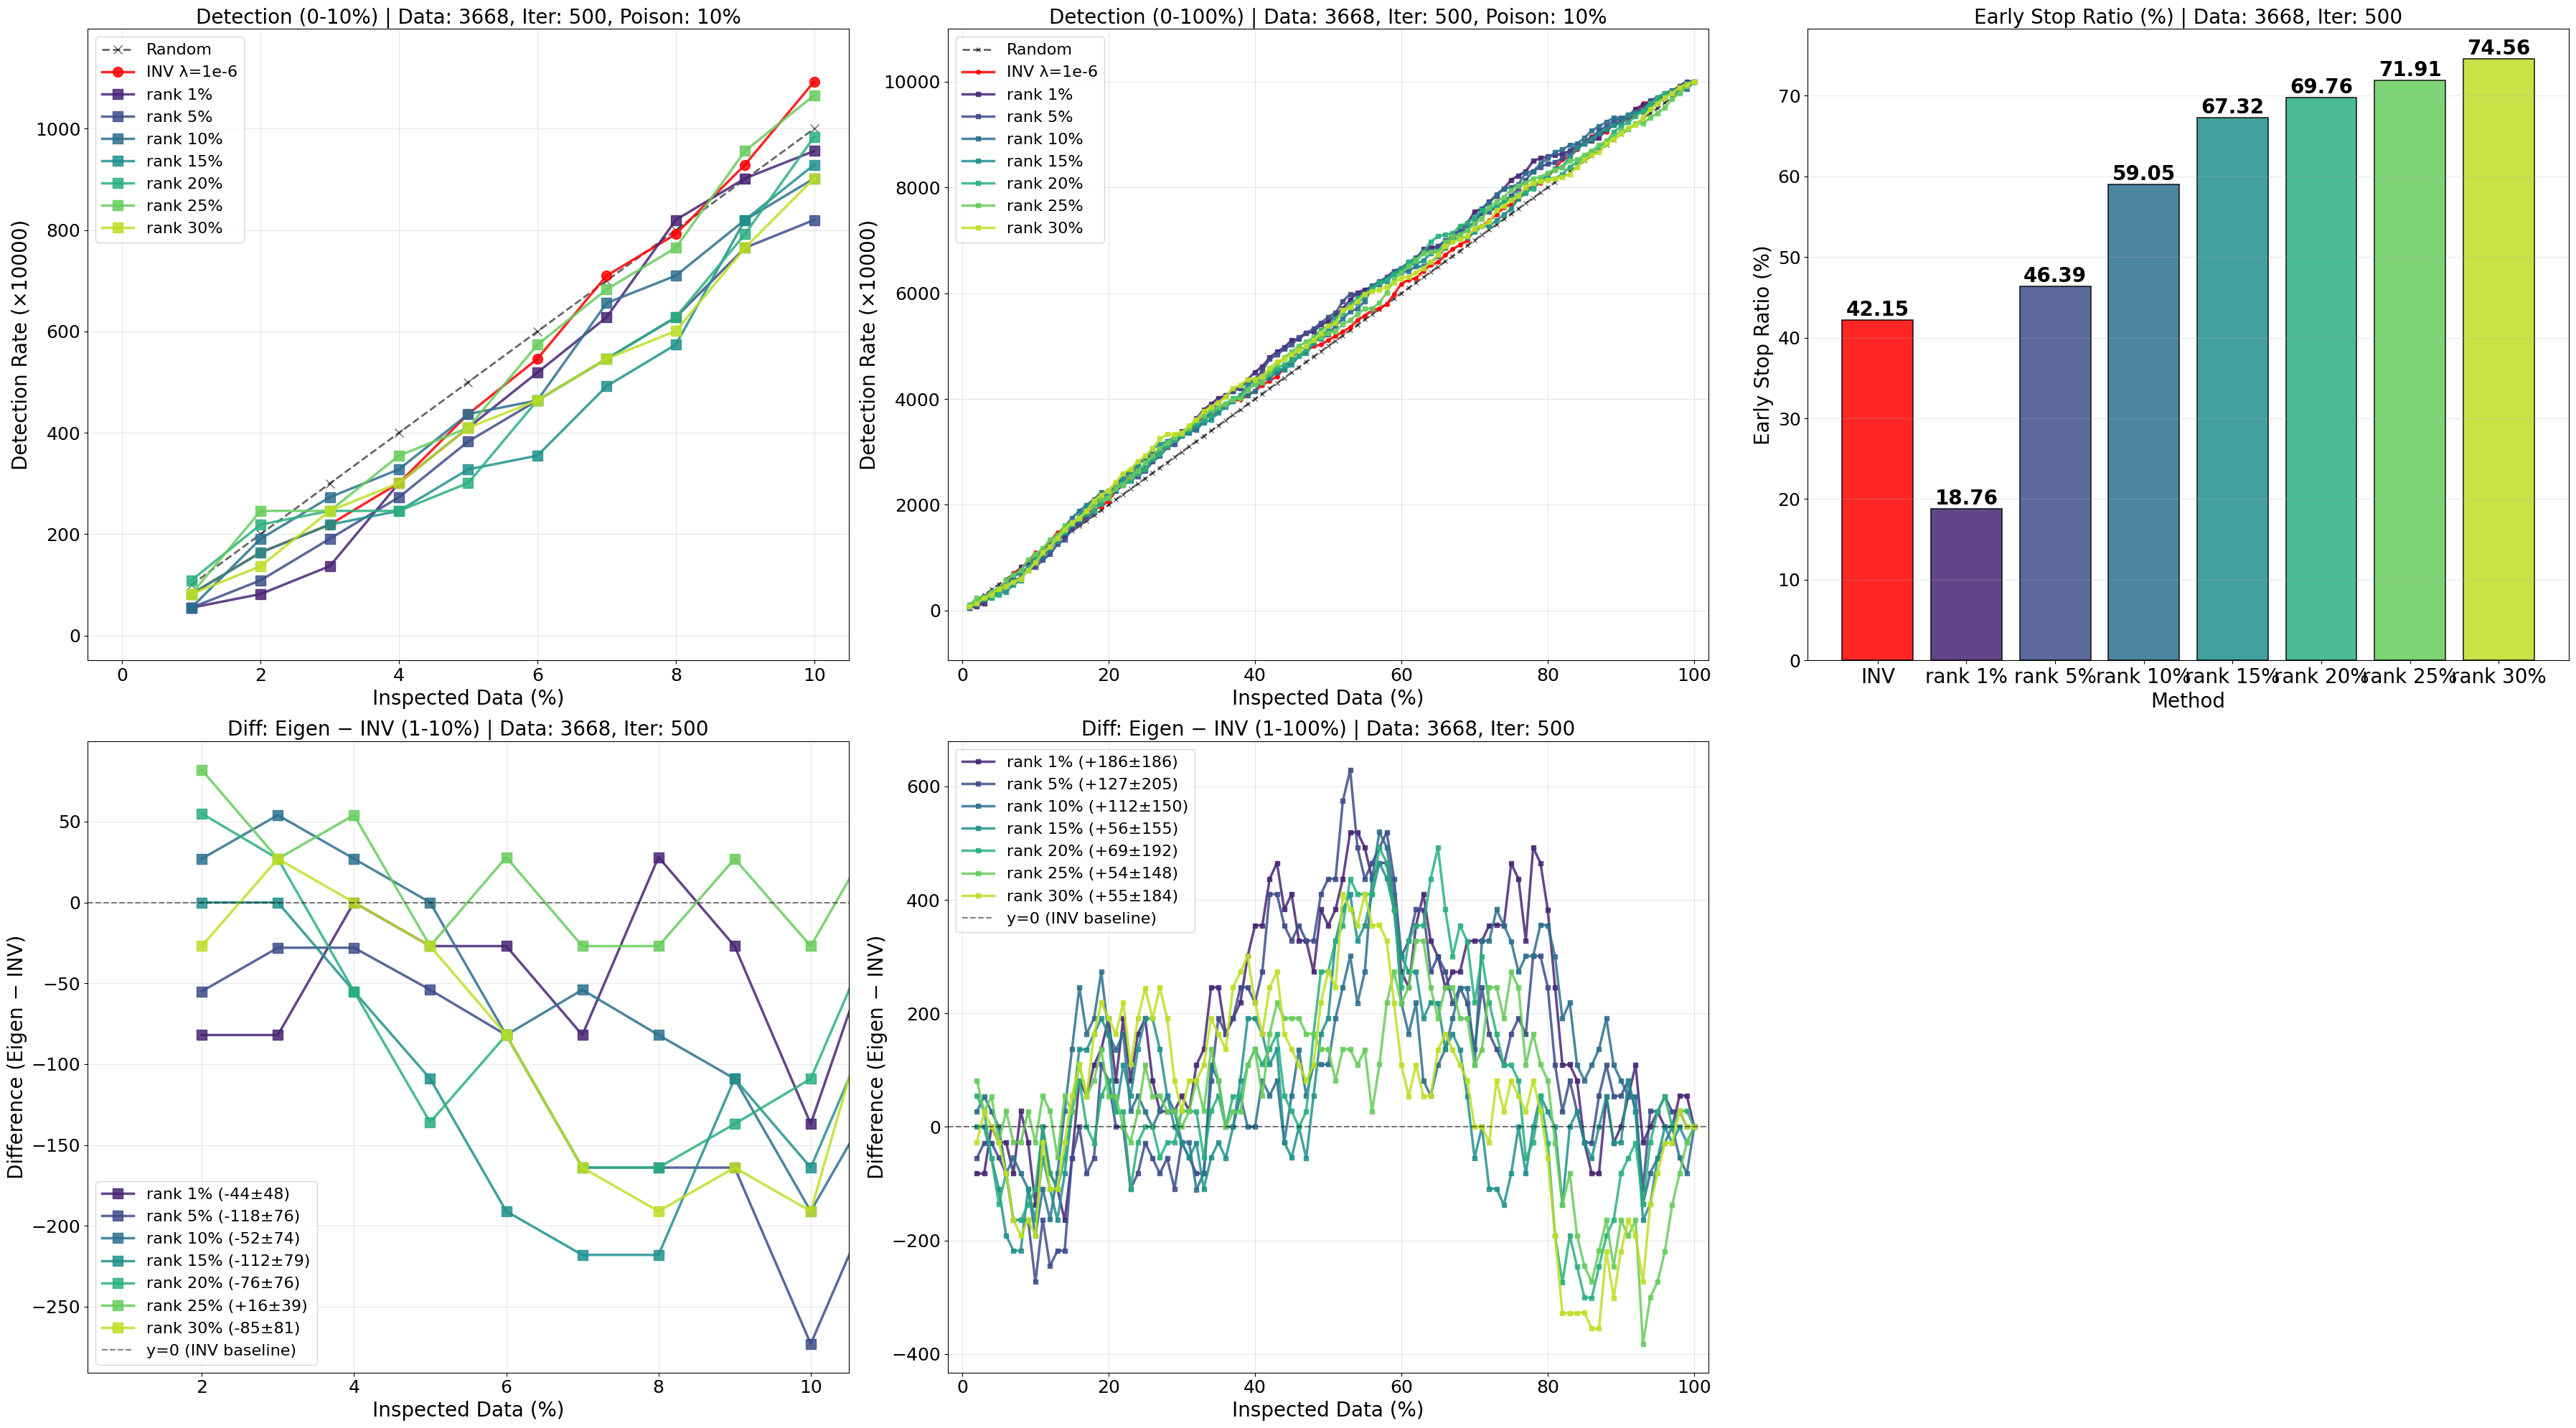

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 3668
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [82, 164, 219, 301, 437, 546, 710, 792, 929, 1093, 1120, 1311, 1475, 1557, 1612, 1639, 1831, 1913, 1967, 2077, 2268, 2377, 2568, 2623, 2678, 2869, 3005, 3142, 3251, 3333, 3415, 3525, 3661, 3661, 3770, 3907, 3962, 3989, 4071, 4153, 4262, 4344, 4426, 4590, 4699, 4809, 4918, 5000, 5027, 5109, 5191, 5273, 5355, 5492, 5574, 5683, 5710, 5792, 5984, 6175, 6257, 6284, 6421, 6530, 6585, 6721, 6831, 6913, 6995, 7213, 7268, 7377, 7486, 7623, 7678, 7787, 7978, 8005, 8087, 8197, 8361, 8525, 8579, 8716, 8852, 8962, 9016, 9044, 9208, 9235, 9290, 9372, 9590, 9617, 9672, 9727, 9809, 9863, 9945, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [55, 82, 137, 301, 410, 519, 628, 820, 902, 956, 1120, 1230, 1366, 1393, 1557, 1721, 1885, 2022, 2104, 2268, 2350, 2568, 2650, 2787, 2869, 2951, 3033, 3169, 3279, 3388, 3443, 3634, 3798, 3907, 4016, 4071, 4153, 4208, 4372, 4508, 4617, 4781, 4891, 4973, 5109, 5137, 5246, 5273, 5410, 5464, 5574, 5710, 5874, 6011, 6066, 6120, 6175, 6257, 6366, 6448, 6503, 6639, 6831, 6858, 6885, 6967, 7104, 7186, 7322, 7541, 7596, 7732, 7842, 7978, 8142, 8224, 8306, 8497, 8552, 8579, 8607, 8634, 8689, 8798, 8825, 8880, 8934, 9098, 9180, 9235, 9344, 9481, 9563, 9617, 9699, 9727, 9809, 9918, 10000, 10000]
r5_eigen_lam1e_2  = [55, 109, 191, 273, 383, 464, 546, 628, 765, 820, 956, 1066, 1257, 1339, 1557, 1639, 1749, 1858, 2077, 2158, 2268, 2377, 2459, 2541, 2650, 2814, 2923, 3087, 3142, 3306, 3361, 3443, 3579, 3743, 3962, 4071, 4153, 4235, 4317, 4372, 4536, 4754, 4836, 4945, 5027, 5164, 5246, 5328, 5437, 5546, 5628, 5847, 5984, 5984, 6011, 6148, 6202, 6311, 6421, 6475, 6585, 6667, 6803, 6803, 6885, 6995, 7049, 7158, 7213, 7350, 7514, 7541, 7623, 7732, 7842, 7978, 8142, 8306, 8388, 8443, 8470, 8552, 8661, 8743, 8825, 8934, 9071, 9153, 9262, 9290, 9372, 9399, 9481, 9645, 9699, 9781, 9836, 9891, 9945, 10000]
r10_eigen_lam1e_2 = [55, 191, 273, 328, 437, 464, 656, 710, 820, 902, 1011, 1148, 1393, 1585, 1749, 1885, 1995, 2104, 2240, 2240, 2404, 2541, 2596, 2678, 2705, 2869, 3033, 3197, 3279, 3306, 3388, 3415, 3579, 3770, 3852, 3907, 3962, 4044, 4071, 4153, 4344, 4399, 4508, 4563, 4754, 4945, 4973, 5109, 5137, 5219, 5383, 5519, 5656, 5710, 5847, 6120, 6230, 6284, 6393, 6393, 6421, 6503, 6503, 6585, 6694, 6858, 7022, 7158, 7240, 7322, 7596, 7705, 7869, 7978, 8005, 8060, 8279, 8306, 8443, 8552, 8661, 8716, 8798, 8825, 8934, 9071, 9153, 9235, 9317, 9317, 9344, 9426, 9454, 9536, 9617, 9699, 9809, 9809, 9863, 10000]
r15_eigen_lam1e_2 = [82, 164, 219, 246, 328, 355, 492, 574, 820, 929, 1066, 1202, 1311, 1475, 1639, 1776, 1967, 2077, 2158, 2240, 2295, 2486, 2623, 2760, 2869, 3060, 3142, 3197, 3251, 3306, 3361, 3497, 3552, 3607, 3743, 3852, 3962, 4071, 4262, 4344, 4426, 4454, 4563, 4563, 4645, 4809, 4863, 5055, 5191, 5301, 5519, 5656, 5765, 5820, 5929, 6093, 6175, 6230, 6366, 6475, 6530, 6557, 6612, 6749, 6803, 6858, 6995, 7049, 7049, 7158, 7268, 7268, 7377, 7486, 7596, 7787, 7896, 8005, 8142, 8224, 8361, 8388, 8579, 8743, 8825, 8907, 9016, 9098, 9180, 9208, 9372, 9399, 9426, 9481, 9617, 9727, 9781, 9863, 9918, 10000]
r20_eigen_lam1e_2 = [109, 219, 246, 246, 301, 464, 546, 628, 792, 984, 1120, 1230, 1366, 1503, 1639, 1721, 1831, 1885, 2022, 2158, 2295, 2404, 2459, 2596, 2678, 2869, 2951, 3115, 3224, 3361, 3443, 3552, 3607, 3689, 3825, 3907, 4016, 4044, 4180, 4290, 4372, 4481, 4590, 4645, 4727, 4809, 4945, 5164, 5301, 5383, 5519, 5628, 5792, 5902, 5984, 6093, 6202, 6257, 6366, 6421, 6585, 6639, 6776, 6967, 7077, 7104, 7131, 7268, 7322, 7432, 7568, 7596, 7650, 7732, 7787, 7869, 7923, 7978, 8142, 8169, 8169, 8251, 8388, 8470, 8552, 8661, 8770, 8852, 9044, 9153, 9235, 9344, 9454, 9590, 9699, 9781, 9809, 9891, 9973, 10000]
r25_eigen_lam1e_2 = [82, 246, 246, 355, 410, 574, 683, 765, 956, 1066, 1175, 1339, 1421, 1612, 1639, 1749, 1885, 1995, 2104, 2131, 2322, 2377, 2541, 2650, 2787, 2923, 3060, 3169, 3279, 3333, 3443, 3607, 3689, 3798, 3852, 3907, 3989, 4016, 4180, 4290, 4317, 4508, 4645, 4781, 4891, 5000, 5082, 5164, 5164, 5246, 5273, 5410, 5492, 5601, 5710, 5710, 5820, 6011, 6257, 6393, 6503, 6612, 6749, 6776, 6776, 6967, 7077, 7104, 7186, 7322, 7404, 7623, 7732, 7814, 7951, 8033, 8087, 8169, 8197, 8279, 8333, 8388, 8497, 8525, 8607, 8689, 8798, 8880, 8962, 9071, 9098, 9208, 9208, 9317, 9399, 9508, 9672, 9781, 9918, 10000]
r30_eigen_lam1e_2 = [82, 137, 246, 301, 410, 464, 546, 601, 765, 902, 1093, 1202, 1366, 1530, 1667, 1749, 1885, 2077, 2186, 2268, 2432, 2596, 2678, 2814, 2923, 3060, 3251, 3333, 3333, 3361, 3497, 3607, 3770, 3852, 3934, 4044, 4208, 4262, 4372, 4372, 4426, 4590, 4699, 4754, 4836, 4918, 5000, 5109, 5246, 5383, 5437, 5683, 5738, 5847, 5984, 6038, 6066, 6120, 6202, 6284, 6311, 6393, 6475, 6585, 6721, 6885, 6967, 7022, 7077, 7213, 7268, 7350, 7568, 7650, 7760, 7842, 8005, 8087, 8115, 8142, 8169, 8197, 8251, 8388, 8525, 8607, 8661, 8825, 8907, 9016, 9126, 9180, 9317, 9481, 9590, 9699, 9781, 9891, 9945, 10000]

# Early stop ratios (%)
inv_early_stop       = [42.15]
r1_eigen_early_stop  = [18.76]
r5_eigen_early_stop  = [46.39]
r10_eigen_early_stop = [59.05]
r15_eigen_early_stop = [67.32]
r20_eigen_early_stop = [69.76]
r25_eigen_early_stop = [71.91]
r30_eigen_early_stop = [74.56]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()